In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [17]:


# 1. Load the Excel data
file_path = '/content/Copy of online_retail_II.xlsx'

df = pd.read_excel(file_path, sheet_name=0)



In [18]:


# 2. Data Cleaning
# Remove missing Customer IDs, non-positive quantities & prices, and cancellations (Invoices starting with 'C')
df = df[df['Customer ID'].notnull()]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df = df[~df['Invoice'].astype(str).str.startswith('C')]



In [19]:

# 3. Define Cohort Month and Transaction Month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Cohort month is the customer's very first purchase month
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')




In [20]:

# 4. Calculate Cohort Index (Months Elapsed)
year_diff = df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year
month_diff = df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month
df['CohortIndex'] = year_diff * 12 + month_diff



In [21]:

# 5. Build the Cohort Retention Matrix
cohort_group = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_group.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Base size (Month 0 active customers)
cohort_size = cohort_pivot.iloc[:, 0]

# Calculate Retention Percentage
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100



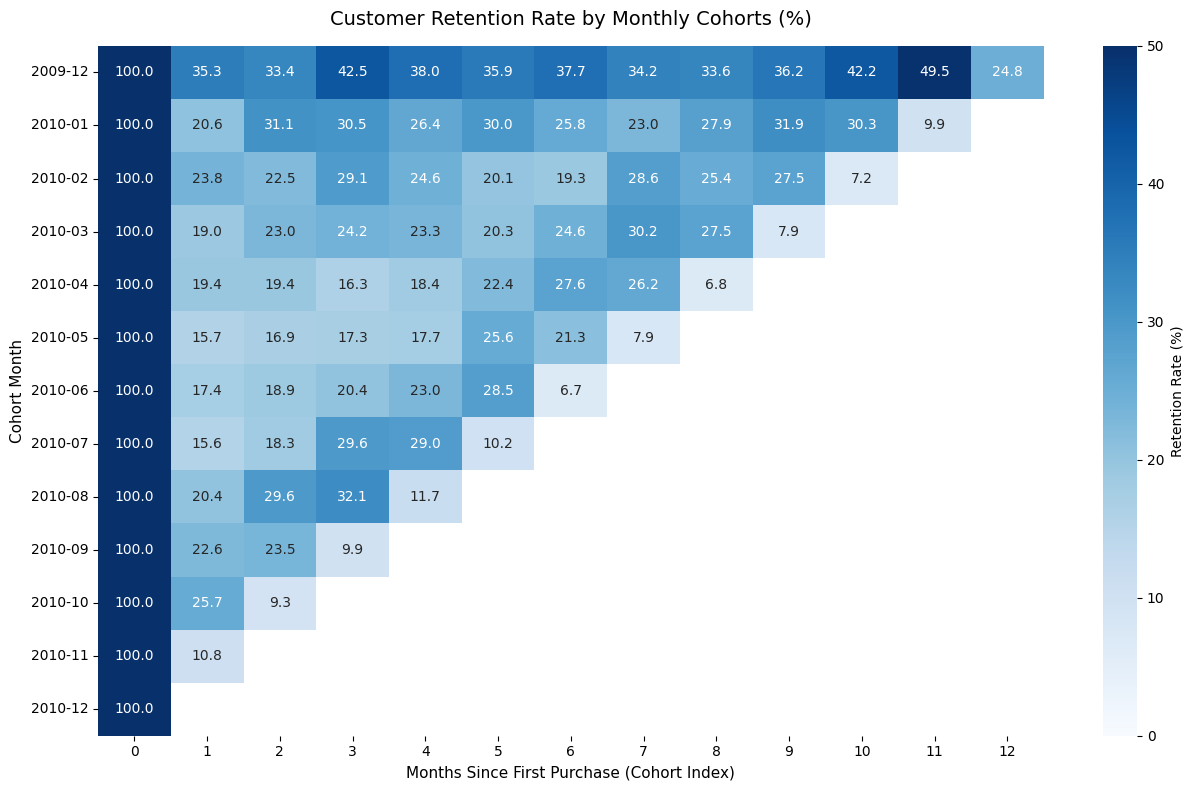

In [22]:

# 6. Deliverable 1: Generate Cohort Retention Heatmap
plt.figure(figsize=(13, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=50,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('Customer Retention Rate by Monthly Cohorts (%)', fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase (Cohort Index)', fontsize=11)
plt.ylabel('Cohort Month', fontsize=11)
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=300)
plt.show()



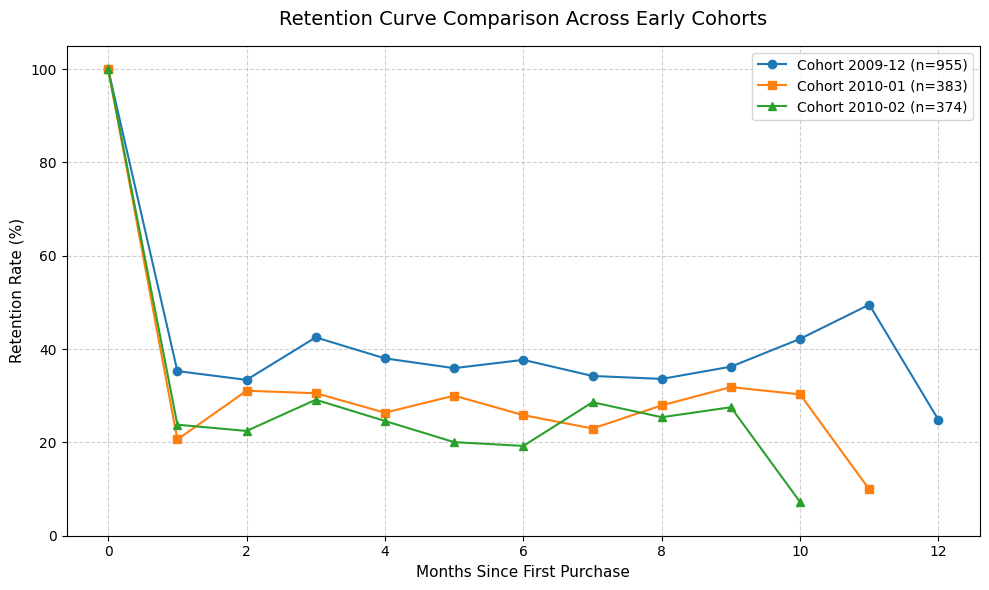

In [23]:
# 7. Deliverable 2: Generate Retention Curve Chart (Comparing 3 Cohorts)
plt.figure(figsize=(10, 6))
plt.plot(retention_matrix.columns, retention_matrix.loc['2009-12'], marker='o', label=f'Cohort 2009-12 (n={int(cohort_size.loc["2009-12"])})')
plt.plot(retention_matrix.columns, retention_matrix.loc['2010-01'], marker='s', label=f'Cohort 2010-01 (n={int(cohort_size.loc["2010-01"])})')
plt.plot(retention_matrix.columns, retention_matrix.loc['2010-02'], marker='^', label=f'Cohort 2010-02 (n={int(cohort_size.loc["2010-02"])})')

plt.title('Retention Curve Comparison Across Early Cohorts', fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase', fontsize=11)
plt.ylabel('Retention Rate (%)', fontsize=11)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('retention_curve.png', dpi=300)
plt.show()